# Conos data sources: Seurat objects, anndata / Seurat / loom files, and

lstar stores

A Conos panel is just a **named list of per-sample objects**, and those
samples do not all have to be pagoda2 objects built in this session.
Conos works with:

- **pagoda2** objects (the [walkthrough](conos-walkthrough.ipynb)
  default),
- **Seurat** objects in memory (v3, v4, or v5),
- samples **read from files** written by other pipelines — **anndata /
  scanpy** (`.h5ad`), **Seurat** (`.h5seurat`), the **loom** format, or
  an **lstar** (zarr) store,
- and even a **mix** of object types in one panel.

pagoda2’s `from*()` constructors read each file format directly (via
HDF5 / zarr — no Python required) into an object Conos can align. This
tutorial shows each route on the bone-marrow / cord-blood panel.

## At a glance

``` r
library(conos)
library(pagoda2)

# Seurat objects in memory work directly:
con <- Conos$new(list(a = seurat_a, b = seurat_b))

# ... or read each sample from a file (each returns a Pagoda2 object; run() adds the PCA Conos aligns on):
s1 <- Pagoda2$fromAnnData("sample1.h5ad")$run(steps = c("variance", "pca"))     # anndata / scanpy
s2 <- Pagoda2$fromH5Seurat("sample2.h5seurat")$run(steps = c("variance", "pca")) # Seurat (SeuratDisk)
s3 <- Pagoda2$fromLoom("sample3.loom")$run(steps = c("variance", "pca"))         # loom
s4 <- Pagoda2$fromLstar("sample4.zarr")$run(steps = c("variance", "pca"))        # lstar (zarr) store
con <- Conos$new(list(s1, s2, s3, s4))

# from here everything is identical to the walkthrough:
con$runGraph(); con$runClustering(); con$runEmbedding()

# an lstar store can also hold a WHOLE collection (panel + joint graph/clusters/embedding):
lstar::write_conos(con) |> lstar::lstar_write("panel.lstar.zarr")  # save the whole Conos
con <- lstar::read_conos("panel.lstar.zarr")                       # ... and reopen it
```

## Contents

- [Example data](#example-data)
- [Seurat objects in memory](#seurat-objects-in-memory)
- [Reading samples from files](#reading-samples-from-files)
- [An entire collection in one
  store](#an-entire-collection-in-one-store)
- [Mixing object types in one panel](#mixing-object-types-in-one-panel)

## Example data

We reuse the `conosPanel` matrices and down-sample them for speed. These
raw count matrices stand in for “data you have on disk”; below we will
turn them into Seurat objects and into files written in several formats,
then read them back.

In [ ]:
library(conos)
library(pagoda2)

set.seed(1)
raw <- lapply(conosPanel::panel, function(m) {
  m <- m[, sample(ncol(m), 700)]
  rownames(m) <- make.unique(rownames(m)); colnames(m) <- make.unique(colnames(m))
  m
})
str(raw, 1)

List of 4
 $ MantonBM1_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonBM2_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonCB1_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonCB2_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots

## Seurat objects in memory

If your samples are already `Seurat` objects, hand them straight to
`Conos$new()` — no conversion needed. Build each one the usual Seurat
way (normalise, find variable features, scale, PCA); Conos aligns on the
PCA. We do two samples here:

In [ ]:
library(Seurat)

seurat.samples <- lapply(raw[1:2], function(cm) {
  s <- CreateSeuratObject(counts = cm)
  s <- NormalizeData(s, verbose = FALSE)
  s <- FindVariableFeatures(s, nfeatures = 2000, verbose = FALSE)
  s <- ScaleData(s, verbose = FALSE)
  RunPCA(s, npcs = 30, verbose = FALSE)
})

In [ ]:
con.seurat <- Conos$new(seurat.samples, n.cores = 1)
con.seurat$runGraph(k = 15, k.self = 5, space = "PCA", ncomps = 30, n.odgenes = 2000, verbose = FALSE)

scale.data
scale.data
scale.data
scale.data

Warning in embedKnnGraph(commute.times, n.neighbors = n.neighbors, names = adj.info$names, : Maximal number of estimated neighbors is 33. Consider increasing min.visited.verts, min.prob or min.prob.lower.

The joint embedding, coloured by sample, shows the two Seurat samples
are well mixed — exactly as for a pagoda2 panel:

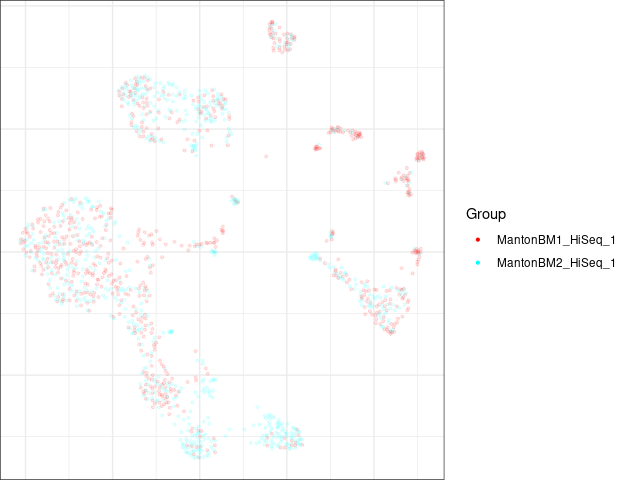

In [ ]:
con.seurat$plotGraph(color.by = "sample", mark.groups = FALSE, alpha = 0.1, show.legend = TRUE)

Clustering, markers, embedding and label transfer all work on Seurat
panels too:

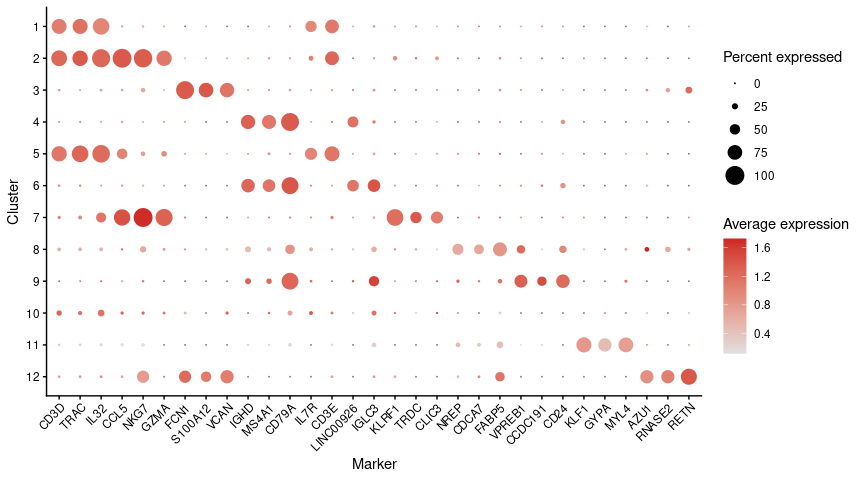

In [ ]:
con.seurat$plotMarkerDotPlot(n.genes.per.group = 3)

## Reading samples from files

More often, each sample lives in a file produced by another pipeline. To
make this runnable we first **write** three samples to files (in
practice they already exist). Here we use the anndata `.h5ad` and lstar
(zarr) formats, both written by pagoda2:

In [ ]:
dir <- file.path(tempdir(), "conos-sources"); dir.create(dir, showWarnings = FALSE)
paths <- c(bm1 = file.path(dir, "bm1.h5ad"),
           bm2 = file.path(dir, "bm2.lstar.zarr"),
           cb1 = file.path(dir, "cb1.h5ad"))
Pagoda2$from(raw[[1]], verbose = FALSE)$export(paths[["bm1"]], format = "h5ad",  overwrite = TRUE)
Pagoda2$from(raw[[2]], verbose = FALSE)$export(paths[["bm2"]], format = "lstar", overwrite = TRUE)
Pagoda2$from(raw[[3]], verbose = FALSE)$export(paths[["cb1"]], format = "h5ad",  overwrite = TRUE)

A Seurat `.h5seurat` (written by `SeuratDisk::SaveH5Seurat`) and a
`.loom` file are read exactly the same way — point the matching
constructor at the file:

In [ ]:
s_h5seurat <- Pagoda2$fromH5Seurat("sample.h5seurat")$run(steps = c("variance", "pca"))
s_loom     <- Pagoda2$fromLoom("sample.loom")$run(steps = c("variance", "pca"))

Read each file with the matching constructor and add the variance + PCA
reduction Conos needs — the result is an ordinary Conos panel:

In [ ]:
samples <- list(
  bm1 = Pagoda2$fromAnnData(paths[["bm1"]])$run(steps = c("variance", "pca"), verbose = FALSE),
  bm2 = Pagoda2$fromLstar(paths[["bm2"]])$run(steps = c("variance", "pca"), verbose = FALSE),
  cb1 = Pagoda2$fromAnnData(paths[["cb1"]])$run(steps = c("variance", "pca"), verbose = FALSE)
)
sapply(samples, function(s) length(getCellNames(s)))

bm1 bm2 cb1 
697 696 700 

These read-from-disk samples integrate exactly like any other:

In [ ]:
con.files <- Conos$new(samples, n.cores = 1)
con.files$runGraph(k = 15, k.self = 5, space = "PCA", ncomps = 30, n.odgenes = 2000, verbose = FALSE)
con.files$runClustering(verbose = FALSE)
con.files$runEmbedding(method = "UMAP", min.visited.verts = 100, verbose = FALSE)

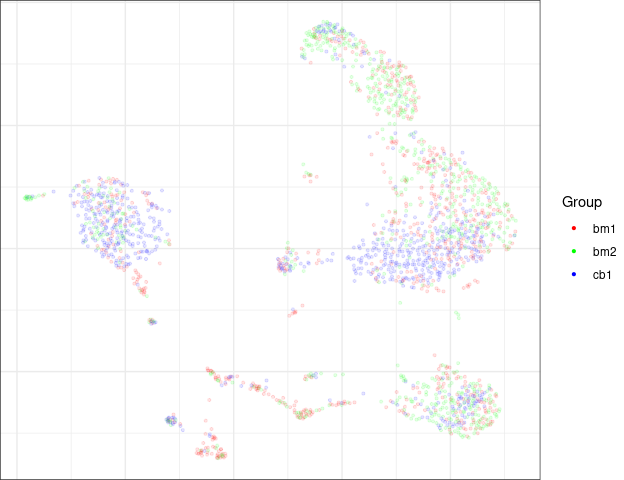

In [ ]:
con.files$plotGraph(color.by = "sample", mark.groups = FALSE, alpha = 0.1, show.legend = TRUE)

## An entire collection in one store

An lstar (zarr) store need not hold a single sample — it can hold a
**whole collection**: every sample *plus* the joint graph, clustering
and embedding. That is conos’s level, so conos writes the entire object
and reads it straight back. Save the panel we just built into one store:

In [ ]:
library(lstar)
collection.path <- file.path(dir, "panel.lstar.zarr")
lstar_write(write_conos(con.files), collection.path)

`read_conos()` reopens it as a live `Conos` — the per-sample objects and
the joint graph / clustering / embedding are all restored, so you can
carry on plotting, finding markers and transferring labels without
recomputing the integration:

In [ ]:
con.reopened <- read_conos(collection.path)
c(samples  = length(con.reopened$samples),
  cells    = length(con.reopened$clusters$leiden$groups),
  clusters = nlevels(con.reopened$clusters$leiden$groups))

 samples    cells clusters 
       3     2093        9 

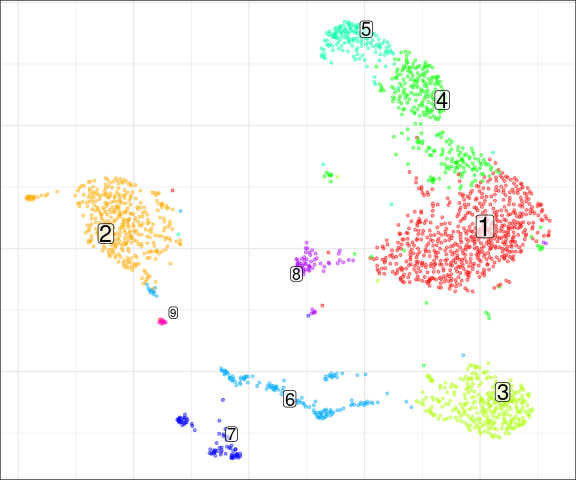

In [ ]:
con.reopened$plotGraph(clustering = "leiden")

## Mixing object types in one panel

A panel may combine sources — say one sample is already a `Pagoda2`
object and another is a `Seurat` object. Conos aligns them together.
Markers are computed **consistently** across the panel: pagoda2 samples
use pagoda2’s own (disk-backed) differential-expression path, and Seurat
(or other) samples are scored with the *same* Wilcoxon test via
`sccore`, so the result does not depend on how each sample was
pre-processed.

In [ ]:
mixed <- list(
  bm_pagoda2 = Pagoda2$from(raw[[2]], verbose = FALSE)$run(steps = c("variance", "pca"), verbose = FALSE),
  cb_seurat  = RunPCA(ScaleData(FindVariableFeatures(NormalizeData(CreateSeuratObject(counts = raw[[4]]),
                       verbose = FALSE), nfeatures = 2000, verbose = FALSE), verbose = FALSE),
                      npcs = 30, verbose = FALSE)
)
sapply(mixed, function(s) class(s)[1])

bm_pagoda2  cb_seurat 
 "Pagoda2"   "Seurat" 

In [ ]:
con.mixed <- Conos$new(mixed, n.cores = 1)
con.mixed$runGraph(k = 15, k.self = 5, space = "PCA", ncomps = 30, n.odgenes = 2000, verbose = FALSE)
con.mixed$runClustering(verbose = FALSE)
con.mixed$runEmbedding(method = "UMAP", min.visited.verts = 100, verbose = FALSE)

Warning in embedKnnGraph(commute.times, n.neighbors = n.neighbors, names = adj.info$names, : Maximal number of estimated neighbors is 35. Consider increasing min.visited.verts, min.prob or min.prob.lower.

The pagoda2 and Seurat samples interleave in the joint embedding:

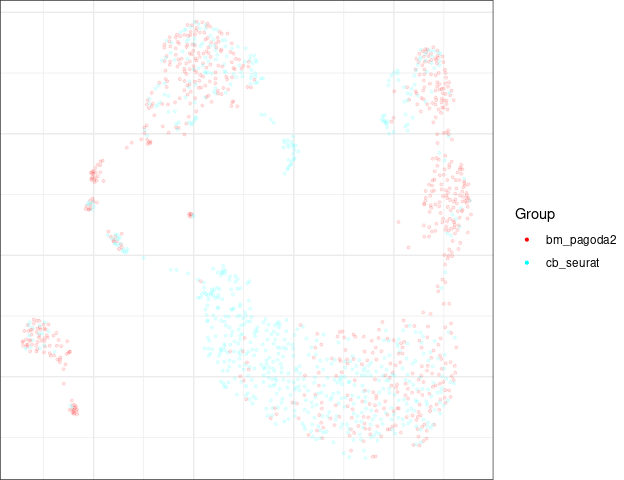

In [ ]:
con.mixed$plotGraph(color.by = "sample", mark.groups = FALSE, alpha = 0.1, show.legend = TRUE)

And markers — computed identically for both sample types — give a clean
per-cluster picture:

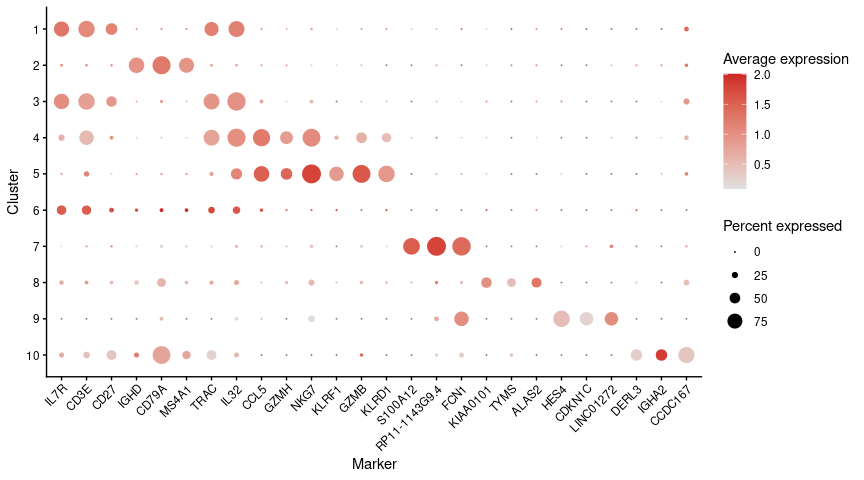

In [ ]:
con.mixed$plotMarkerDotPlot(n.genes.per.group = 3)

Whatever the source — pagoda2 or Seurat, in memory or on disk — once the
samples are in a list, the rest of the analysis is the
[walkthrough](conos-walkthrough.ipynb), and the alignment knobs are in
the [advanced tutorial](conos-advanced.ipynb).